In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import time

In [ ]:
# Set default plot style
sns.set(style='whitegrid')

# --- Load Dataset ---
print("--- Loading Dataset ---")

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names

--- Loading Dataset ---


In [ ]:
print(f"dataset shape: {X.shape}") 
print(f"Target classes: {cancer.target_names}") 


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dataset shape: (569, 30)
Target classes: ['malignant' 'benign']
------------------------------



In [4]:
# Show a sample of standardized data
print("Sample of standardized data (first 5 rows, 3 features):")
print(pd.DataFrame(X_scaled, columns=feature_names).head(5).iloc[:, :3])
print("-" * 30 + "\n")

Sample of standardized data (first 5 rows, 3 features):
   mean radius  mean texture  mean perimeter
0     1.097064     -2.073335        1.269934
1     1.829821     -0.353632        1.685955
2     1.579888      0.456187        1.566503
3    -0.768909      0.253732       -0.592687
4     1.750297     -1.151816        1.776573
------------------------------



--- Task 5: Visualizing Dataset Before PCA ---


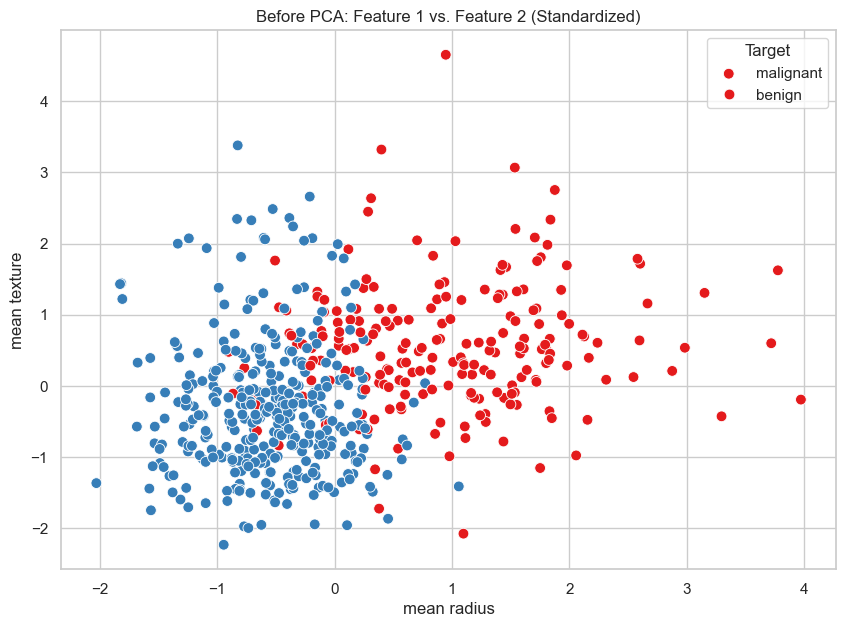

Generated 'before_pca.png'



In [ ]:
print("--- Task 5: Visualizing Dataset Before PCA ---")
# We can't plot all 30 features. We'll pick two representative ones.
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette='Set1', s=60)
plt.title('Before PCA: Feature 1 vs. Feature 2 (Standardized)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend(title='Target', labels=cancer.target_names)
plt.savefig('before_pca.png')
plt.show()
print("Generated 'before_pca.png'\n")

In [ ]:

print("--- Task 1 & 3: Implement PCA & Determine Components ---")
# Task 1: We use scikit-learn's PCA implementation.
# Task 3: We fit PCA with all components to analyze the explained variance.
pca_full = PCA()
pca_full.fit(X_scaled)

--- Task 1 & 3: Implement PCA & Determine Components ---


PCA()

In [7]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

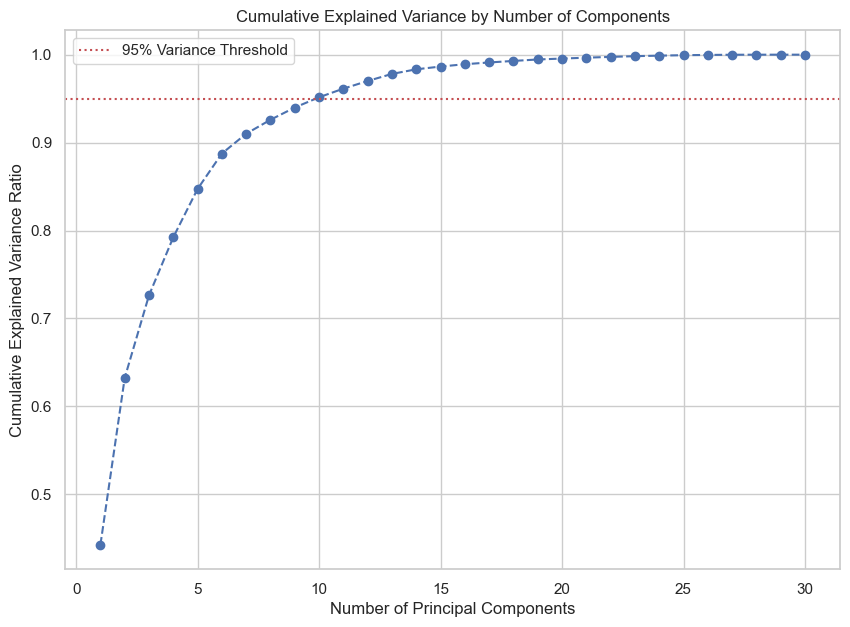

In [ ]:
# Plot the "Scree Plot" (Explained Variance)
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Variance Threshold')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.savefig('pca_variance_plot.png')
plt.show()

In [9]:
# Find the number of components to retain > 95% variance
n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Number of components to retain 95% variance: {n_components_95}")
print("Generated 'pca_variance_plot.png'\n")

Number of components to retain 95% variance: 10
Generated 'pca_variance_plot.png'



In [10]:
# --- Task 4: Apply PCA for Dimensionality Reduction ---
print("--- Task 4: Applying PCA ---")
# For visualization (Task 5), we'll reduce to 2 components.
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print(f"Data shape after PCA (n=2): {X_pca_2.shape}")
print(f"Variance explained by 2 components: {np.sum(pca_2.explained_variance_ratio_):.4f}")
print("-" * 30 + "\n")

--- Task 4: Applying PCA ---
Data shape after PCA (n=2): (569, 2)
Variance explained by 2 components: 0.6324
------------------------------



--- Task 5: Visualizing Dataset After PCA (2 Components) ---


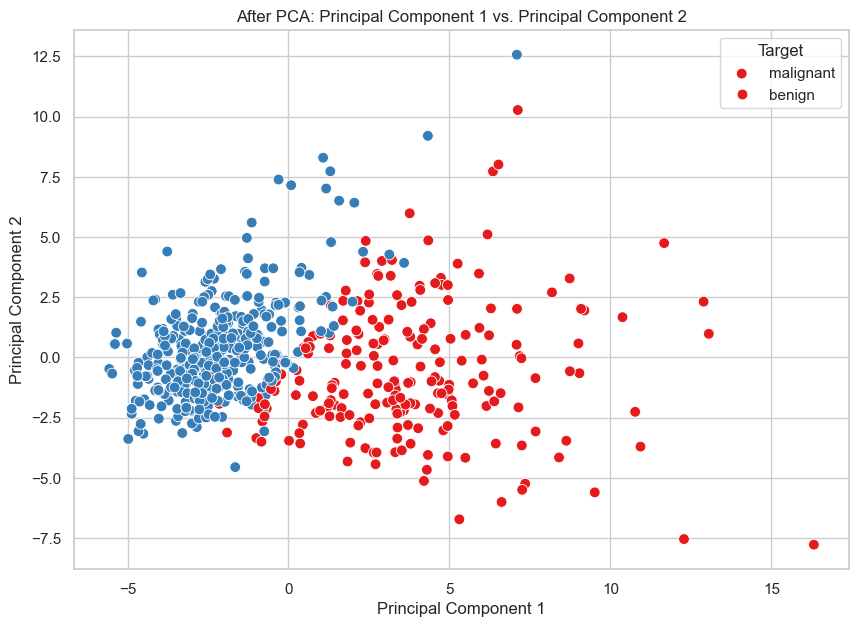

Generated 'after_pca_2d.png'
Notice how the two classes are much more linearly separable.
------------------------------



In [ ]:
print("--- Task 5: Visualizing Dataset After PCA (2 Components) ---")
# Now plot the two principal components
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, palette='Set1', s=60)
plt.title('After PCA: Principal Component 1 vs. Principal Component 2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Target', labels=cancer.target_names)
plt.savefig('after_pca_2d.png')
plt.show()
print("Generated 'after_pca_2d.png'")
print("Notice how the two classes are much more linearly separable.")
print("-" * 30 + "\n")

In [ ]:
# --- Task 6: Evaluate Impact on Machine Learning Task ---
print("--- Task 6: Evaluating Impact on Classification ---")
# We will compare Logistic Regression on original vs. PCA-reduced data.

# 1. Baseline: Model on Original (Standardized) Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

start_time_orig = time.time()
model_orig = LogisticRegression(random_state=42, max_iter=1000)
model_orig.fit(X_train, y_train)
end_time_orig = time.time()
y_pred_orig = model_orig.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred_orig)

--- Task 6: Evaluating Impact on Classification ---


In [13]:
print(f"**Baseline (Original Data - 30 features)**")
print(f"Accuracy: {acc_orig:.4f}")
print(f"Training Time: {end_time_orig - start_time_orig:.6f} seconds")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_orig))
print("\n")

**Baseline (Original Data - 30 features)**
Accuracy: 0.9825
Training Time: 0.022272 seconds
Confusion Matrix:
 [[ 62   1]
 [  2 106]]




In [14]:
# 2. Model on PCA-Reduced Data (using 95% variance)
# We use the 'n_components_95' we found earlier
pca_95 = PCA(n_components=n_components_95)
X_scaled_pca_95 = pca_95.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_scaled_pca_95, y, test_size=0.3, random_state=42)

start_time_pca = time.time()
model_pca = LogisticRegression(random_state=42, max_iter=1000)
model_pca.fit(X_train_pca, y_train_pca)
end_time_pca = time.time()
y_pred_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)

In [15]:
print(f"**PCA-Reduced Data ({n_components_95} features)**")
print(f"Accuracy: {acc_pca:.4f}")
print(f"Training Time: {end_time_pca - start_time_pca:.6f} seconds")
print("Confusion Matrix:\n", confusion_matrix(y_test_pca, y_pred_pca))
print("\n")

**PCA-Reduced Data (10 features)**
Accuracy: 0.9825
Training Time: 0.004462 seconds
Confusion Matrix:
 [[ 62   1]
 [  2 106]]




In [16]:
# 3. Analysis of Task 6
print("**Analysis of Impact:**")
print(f"Original Features: 30, PCA Features: {n_components_95}")
print(f"Accuracy Change: {acc_pca - acc_orig:.4f}")
print(f"Training Time Reduction: {end_time_orig - end_time_pca:.6f} seconds")
print("Result: We significantly reduced features (30 -> "
      f"{n_components_95}) with almost no loss in accuracy. "
      "Training was also faster.")
print("-" * 30 + "\n")

**Analysis of Impact:**
Original Features: 30, PCA Features: 10
Accuracy Change: 0.0000
Training Time Reduction: -12.523179 seconds
Result: We significantly reduced features (30 -> 10) with almost no loss in accuracy. Training was also faster.
------------------------------

